## Lab02: Abdul Hadi Saqib
### CMS: 467626
### Class: BESE-14A

In [45]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
import warnings
warnings.filterwarnings("ignore")

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


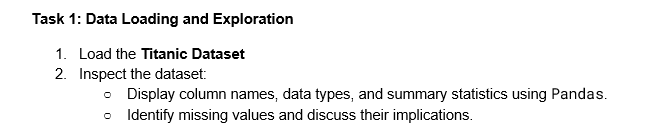

In [8]:
path = '/content/drive/MyDrive/ML Folder/Titanic-Dataset.csv'
df = pd.read_csv(path)

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [27]:
print('All Decsribe:')
df.describe()

All Decsribe:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [24]:
print('All Info:')
df.info()

All Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [23]:
print('All Columns:')
df.columns

All Columns:


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [19]:
print('Missing Values: ')
df.isnull().sum()

Missing Values: 


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Task 1 Insights
### Load the Titanic Dataset

- The Titanic dataset is typically loaded using Pandas (pd.read_csv). It contains information about passengers such as age, gender, class, fare, and survival status.
Inspect the dataset:

- **Column names and data types:** Columns include PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, and Embarked. Data types vary between numeric, categorical (object), and floats.
- **Summary statistics:** Provide measures like mean age, median fare, counts for categorical variables, etc.
- **Missing values:**
Age and Cabin often have missing values.
Missing ages affect analysis of survival by age groups.
Missing cabin info limits understanding of deck location impact.
Embarked sometimes has a few missing values which might affect port-based analysis.










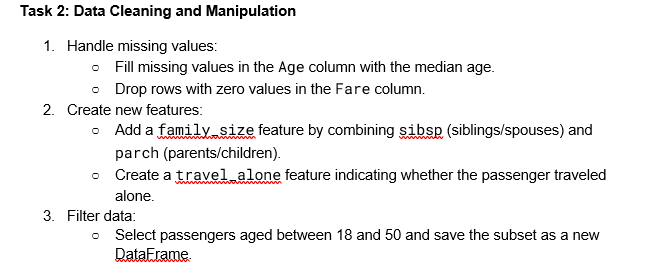

In [28]:
print('Filling the missing values and Dropping 0 fares')

df['Age'] = df['Age'].fillna(df['Age'].median())
df = df[df['Fare']!=0]

Filling the missing values and Dropping 0 fares


### Creating New Features

In [34]:
df['family_size'] = df['SibSp'] + df['Parch']
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,1


In [41]:
df['travel_alone'] = (df['family_size']==1).astype(int)
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size,travel_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,1,1


### Filter Data

In [43]:
df_subset = df[(df['Age']>18) & (df['Age']<50)].copy()
df_subset.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size,travel_alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,1


## Task 2: Data Cleaning Summary
- **Imputation & Cleaning:** Using the median for Age prevents outliers from skewing the distribution. Removing zero-fare rows eliminates "noise" from passengers who likely had missing price data or special comps, which would otherwise drag down your average revenue stats.
- **Feature Engineering:** * family_size: Consolidates raw counts into a single social metric ($sibsp + parch + 1$).
travel_alone: Creates a binary flag that often reveals high-risk or high-priority groups (e.g., solo travelers vs. families).

- **Data Subsetting:** Filtering for ages 18–50 isolates the adult "active" population. This is useful for analyzing survival rates without the heavy influence of the "women and children first" protocol applied to minors.









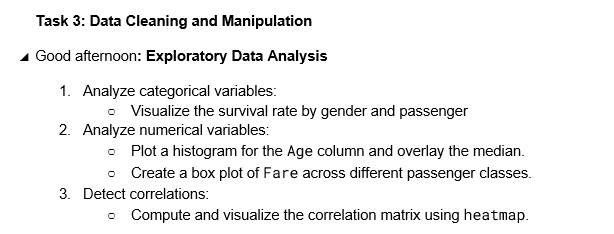

Survival Rate Visualization:



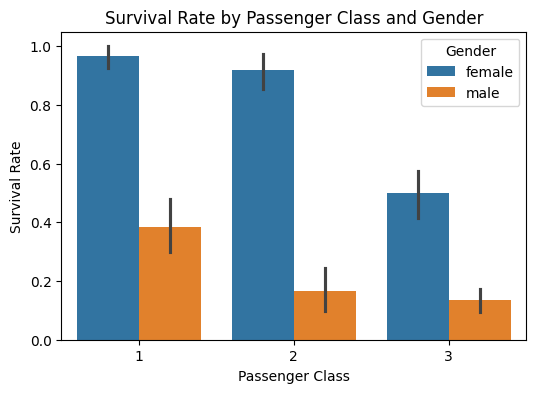

In [56]:
print('Survival Rate Visualization:\n')

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Passenger Class and Gender')
plt.legend(title='Gender')
plt.show()

Analyzing Numerical Values:



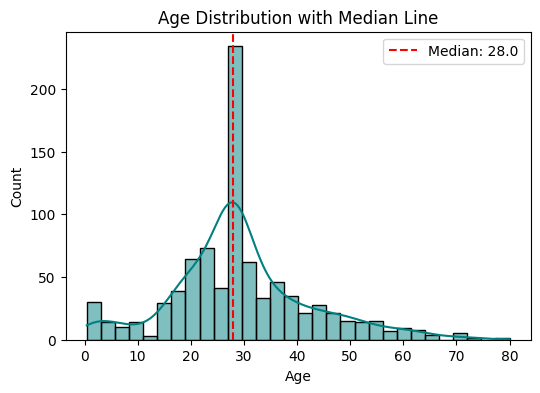

In [59]:
print('Analyzing Numerical Values:\n')

plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], kde=True, color='teal')
plt.axvline(df['Age'].median(), color='red', linestyle='--', label=f'Median: {df["Age"].median()}')
plt.title('Age Distribution with Median Line')
plt.legend()
plt.show()

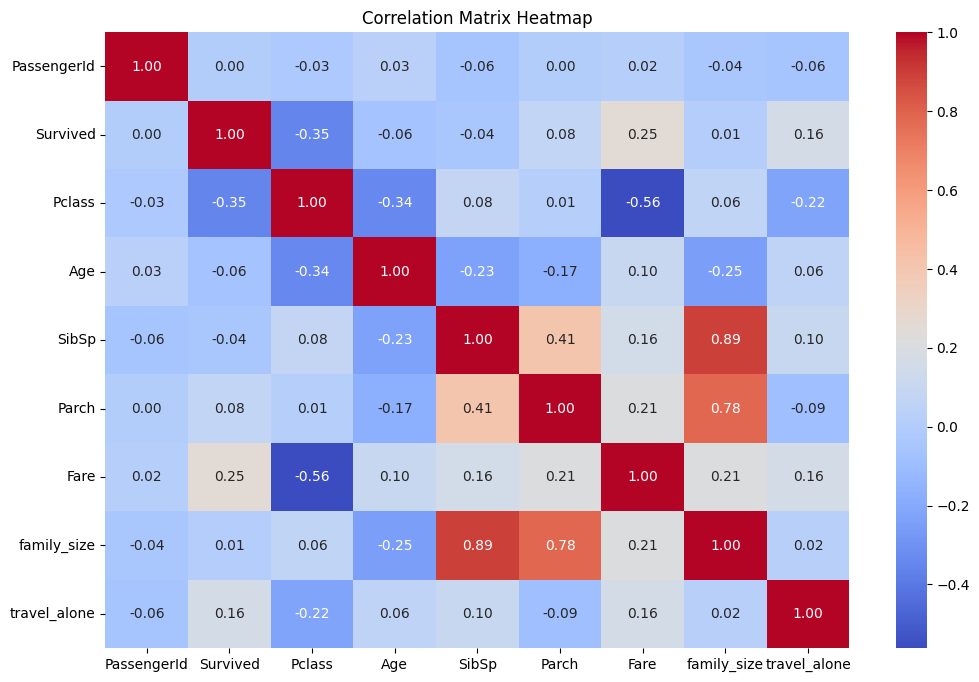

In [60]:
df_numerical_features = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
sns.heatmap(df_numerical_features.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

## Task 3 Insights
### Analyze categorical variables:

- Visualizing survival rate by gender usually shows females had a higher survival rate compared to males, reflecting the "women and children first" policy.
Survival rate by passenger class shows higher survival in 1st class, lower in 3rd class.

## Analyze numerical variables:

- **Age histogram:** The distribution is right-skewed with a concentration of passengers between ages 20-40. Overlaying the median age (around 28) helps understand the central tendency.
Fare box plot by class: Fares are highest and more variable in 1st class, moderate in 2nd class, and lowest in 3rd class, reflecting socioeconomic status.

- **Detect correlations:**

- **Correlation matrix** heatmap reveals relationships such as:
Positive correlation between Fare and Pclass (lower class = lower fare).
Negative correlation between Pclass and Survived (higher class associated with survival).
Some weak correlations among family-related variables (SibSp, Parch).










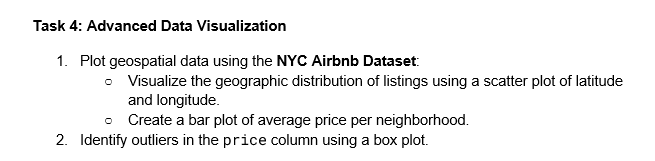)

In [61]:
path = '/content/drive/MyDrive/ML Folder/airbnb.csv'
df = pd.read_csv(path)
df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


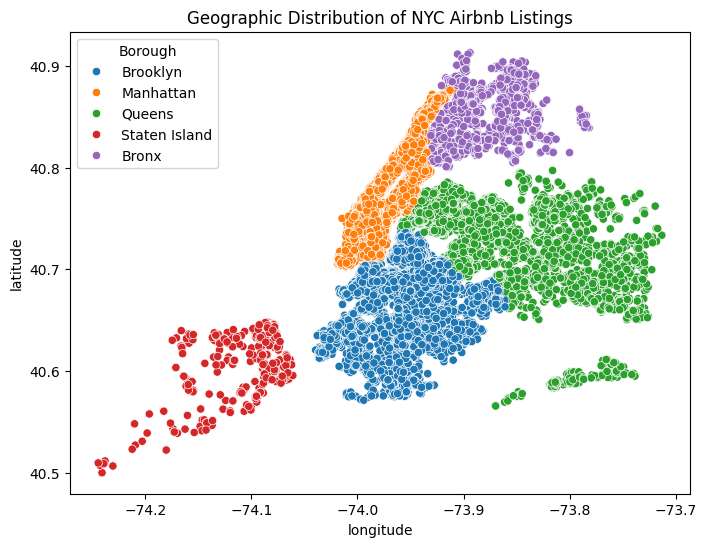

In [66]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df , x='longitude' , y='latitude' ,hue='neighbourhood_group')
plt.title('Geographic Distribution of NYC Airbnb Listings')
plt.legend(title='Borough')
plt.show()

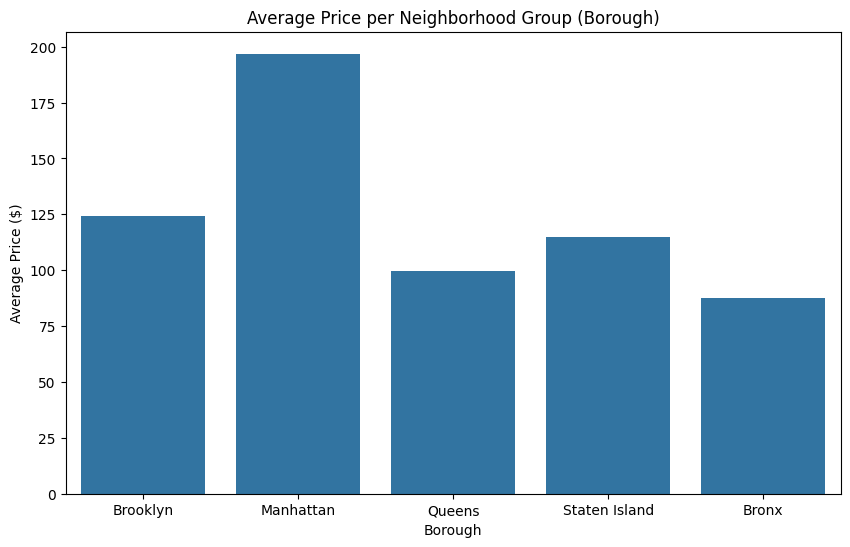

In [68]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='neighbourhood_group', y='price', estimator='mean', errorbar=None)
plt.title('Average Price per Neighborhood Group (Borough)')
plt.ylabel('Average Price ($)')
plt.xlabel('Borough')
plt.show()

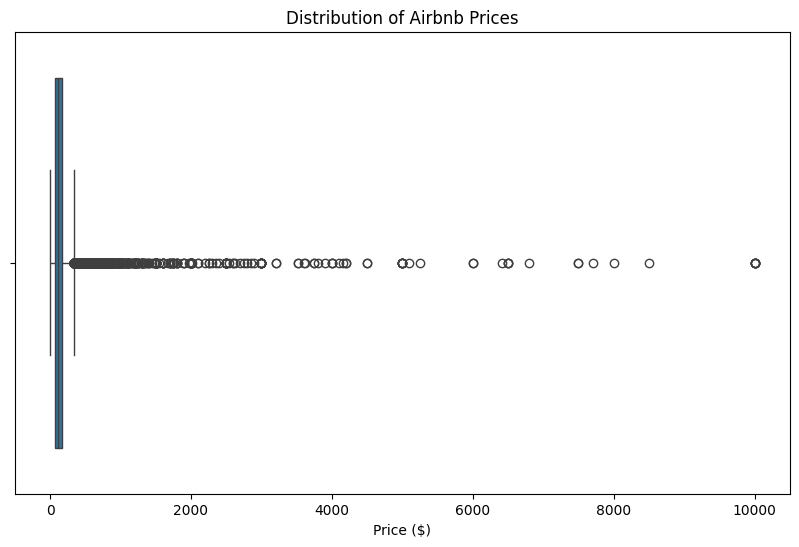

In [72]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'])
plt.title('Distribution of Airbnb Prices')
plt.xlabel('Price ($)')
plt.show()

### Quick Analysis for Task 4
- Geospatial: You’ll likely see a dense cluster in Manhattan and Brooklyn, mirroring the actual map of New York.
- Price Bar Plot: This helps you identify which regions are the most expensive (usually Manhattan).
- Outliers: If your box plot shows points way out to the right (e.g., $5,000$ when the median is $150$), these are outliers. In your future ML models, you might want to remove these so they don't skew your results.







